# Verification: Flow Past Periodic Array of Spheres

This notebook verifies the CFD solver by simulating flow through a simple cubic array of spheres at low Reynolds number ($Re \approx 0.01$).

We compare the computed Drag Coefficient ($K$) against reference values from Zick & Homsy (1982) and Sangani & Acrivos (1982).

## Objectives
1. **Parameter Sweep**: Calculate $K$ for solid volume fractions $\phi \in [0.05, 0.5]$.
2. **Grid Convergence**: Verify numerical convergence for the dense case $\phi=0.5$.
3. **Visualization**: Export flow fields to VTI and plot results.

In [1]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
import time

# Add build directory to path to import pnm_backend
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '../build')))
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '../cfd_utils')))
import pnm_backend
from vti import save_vti

# Ensure output directory exists
os.makedirs('output', exist_ok=True)

## Helper Functions

In [2]:
def generate_sc_sdf(phi, res_n, L=1.0):
    """Generates Signed Distance Field for a Simple Cubic array of spheres."""
    # Use (Nx, Ny, Nz) shape with Fortran-order (x varies fastest) for consistency with user preference
    dx = L/res_n
    x = np.linspace(0, L, res_n, endpoint=False) + 0.5 * dx
    y = np.linspace(0, L, res_n, endpoint=False) + 0.5 * dx
    z = np.linspace(0, L, res_n, endpoint=False) + 0.5 * dx
    
    # indexing='ij' gives shape (Nx, Ny, Nz)
    X, Y, Z = np.meshgrid(x, y, z, indexing='ij')
    
    R = (phi * 3.0 / (4.0 * np.pi))**(1.0/3.0) * L
    
    xc, yc, zc = L/2, L/2, L/2
    dist = np.sqrt((X - xc)**2 + (Y - yc)**2 + (Z - zc)**2)
    sdf = dist - R
    
    # ravel(order='F') ensures we flatten (x,y,z) as x-fast, y-med, z-slow
    # which matches the C++ linear index: idx = z*ny*nx + y*nx + x
    return sdf.ravel(order='F').astype(np.float32), R, (dx, dx, dx)

def get_analytical_k(phi):
    """Returns reference Drag Factor K from Sangani & Acrivos (1982) for Simple Cubic."""
    phis = np.array([0.05, 0.10, 0.20, 0.30, 0.40, 0.50])
    ks   = np.array([4.95, 6.10, 9.10, 13.6, 21.6, 39.5])
    if phi < phis[0]: return 1.0 # Dilute limit approximation
    return np.interp(phi, phis, ks)

def compute_velocity_at_centers(u, v, w):
    """Interpolate staggered velocities to cell centers and compute magnitude."""
    # u is at (i, j+0.5, k+0.5), interpolate to (i+0.5, j+0.5, k+0.5)
    u_c = 0.5 * (u + np.roll(u, -1, axis=0))
    # v is at (i+0.5, j, k+0.5), interpolate to (i+0.5, j+0.5, k+0.5)
    v_c = 0.5 * (v + np.roll(v, -1, axis=1))
    # w is at (i+0.5, j+0.5, k), interpolate to (i+0.5, j+0.5, k+0.5)
    w_c = 0.5 * (w + np.roll(w, -1, axis=2))

    return u_c, v_c, w_c


## Simulation Kernel

In [3]:
class SimulationRunner:
    def __init__(self, phi, res_n, L=1.0):
        self.phi = phi
        self.res_n = res_n
        self.L = L
        
        self.sdf_values, self.R, self.spacing_tuple = generate_sc_sdf(phi, res_n, L)
        self.dx, self.dy, self.dz = self.spacing_tuple
        
        # Setup Data Objects
        self.sdf_data = pnm_backend.SDFData(
            self.sdf_values, 
            pnm_backend.int3(res_n, res_n, res_n),
            pnm_backend.float3(0,0,0),
            pnm_backend.float3(self.dx, self.dy, self.dz)
        )
        self.solver = pnm_backend.CFDSolver(
            pnm_backend.int3(res_n, res_n, res_n), 
            pnm_backend.float3(self.dx, self.dy, self.dz)
        )
        self.solver.initialize(self.sdf_data)
        
        # Parameters (Low Re)
        self.rho = 0.0
        self.mu = 1.0
        self.f_mag = 1.0
        self.solver.set_body_force(pnm_backend.float3(self.f_mag, 0, 0))
        self.solver.set_rho(self.rho)
        self.solver.set_mu(self.mu)
        
        # Solver Parameters for Implicit Scheme
        self.solver.set_pressure_solver_params(50)
        self.solver.set_velocity_solver_params(2)
        #self.solver.set_diffusion_theta(1.0)
        self.solver.set_outer_iterations(800)
        self.solver.set_outer_tolerance(0.0)

    def run(self, dt=1.0, max_steps=100, save_output=False, filename=None):
        # Explicit limit is roughly 0.5*dx^2/nu ~ 0.5 * (1/64)^2 / 0.01 ~ 0.01
        # We use a much larger step to speed up convergence to steady state.
        
        u_mean_history = []
        
        print(f"Running phi={self.phi:.3f}, Res={self.res_n}^3, dt={dt:.4f}...")
        
        start_time = time.time()
        for i in range(max_steps):
            # Use Implicit Step
            self.solver.step(dt)
            
            if i % 50 == 0:
                u_field = np.array(self.solver.get_u())
                u_mean = np.mean(u_field)
                u_mean_history.append(u_mean)
                
                if len(u_mean_history) > 5:
                    # Relative change convergence check
                    if abs(u_mean_history[-1]) > 1e-12:
                        err = abs(u_mean_history[-1] - u_mean_history[-2]) / abs(u_mean_history[-1])
                        if err < 1e-5:
                            print(f"  Converged at step {i}. Mean Vel = {u_mean:.6e}")
                            break
        
        elapsed = time.time() - start_time
        u = np.array(self.solver.get_u())
        U_sup = np.mean(u)
        
        # Calculate K
        F_drag = self.f_mag * (self.L**3) * (1-self.phi)
        K = F_drag / (6.0 * np.pi * self.mu * self.R * U_sup)
        
        print(f"  K_sim = {K:.4f} (Time: {elapsed:.2f}s)")
        
        u = u.reshape((self.res_n,self.res_n,self.res_n), order='F')
        p = np.array(self.solver.get_p()).reshape((self.res_n,self.res_n,self.res_n), order='F')
        if save_output and filename:            
            v = np.array(self.solver.get_v()).reshape((self.res_n,self.res_n,self.res_n), order='F')
            w = np.array(self.solver.get_w()).reshape((self.res_n,self.res_n,self.res_n), order='F')
            u_c, v_c, w_c = compute_velocity_at_centers(u, v, w)
            save_vti(filename, (self.res_n, self.res_n, self.res_n), (self.dx, self.dy, self.dz), u_c, v_c, w_c, p)

        p_prof_1d = np.mean(p, axis=(1,2))
        u_prof_1d = np.mean(u, axis=(1,2))

        return K, U_sup, p_prof_1d, u_prof_1d

## 1. Parameter Sweep

Running phi=0.300, Res=32^3, dt=1.0000...IBM Geometry Updated.
  Pressure/Center: 1944 IBM cells
  U-Face: 1916
 IBM cells, 21072 fluid cells
  V-Face: 1916 IBM cells, 21072 fluid cells
  W-Face: 1916 IBM cells, 21072 fluid cells
  K_sim = -944595.3225 (Time: 50.57s)


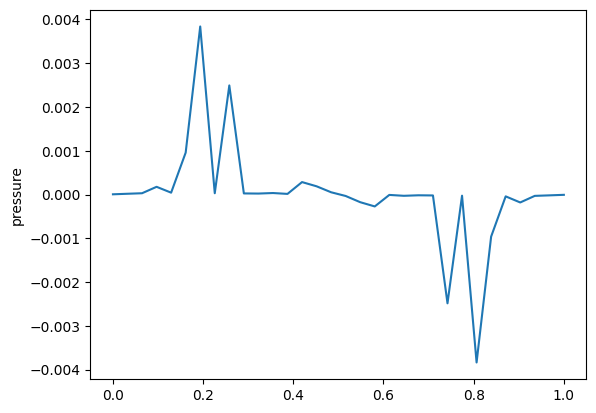

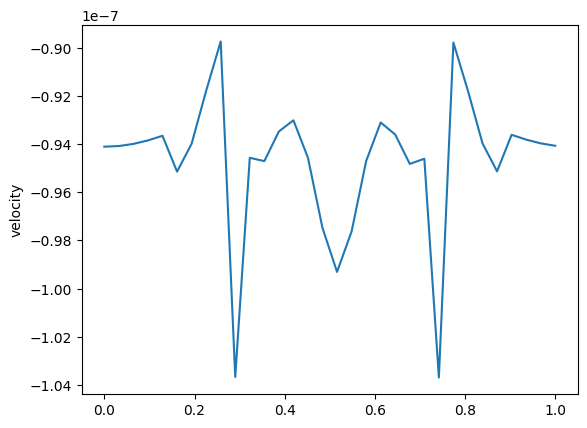


Summary Results:
Phi        K_sim      K_ref      Error %   
----------------------------------------
0.300      -944595.3225 13.6000    -6945653.84


In [4]:
#phis = [0.05, 0.10, 0.20, 0.30, 0.40, 0.50]
phis = [0.30]
res_n = 32

results = []

for phi in phis:
    simulator = SimulationRunner(phi, res_n)
    k_sim, u_sup, p_prof_1d, u_prof_1d = simulator.run(save_output=True, filename=f"output/final_phi_{phi:.2f}.vti", dt = 1.0, max_steps=100)
    k_ref = get_analytical_k(phi)
    results.append({
        'phi': phi,
        'k_sim': k_sim,
        'k_ref': k_ref,
        'error': 100*(k_sim - k_ref)/k_ref
    })
    plt.plot(np.linspace(0,1,res_n), p_prof_1d)
    plt.ylabel('pressure')
    plt.show()
    plt.plot(np.linspace(0,1,res_n), u_prof_1d)
    plt.ylabel('velocity')
    plt.show()

# Output Table
print("\nSummary Results:")
print(f"{'Phi':<10} {'K_sim':<10} {'K_ref':<10} {'Error %':<10}")
print("-"*40)
for res in results:
    print(f"{res['phi']:<10.3f} {res['k_sim']:<10.4f} {res['k_ref']:<10.4f} {res['error']:<10.2f}")

<>:11: SyntaxWarning: invalid escape sequence '\p'
<>:11: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_2435697/2110517439.py:11: SyntaxWarning: invalid escape sequence '\p'
  plt.xlabel('Solid Volume Fraction $\phi$')


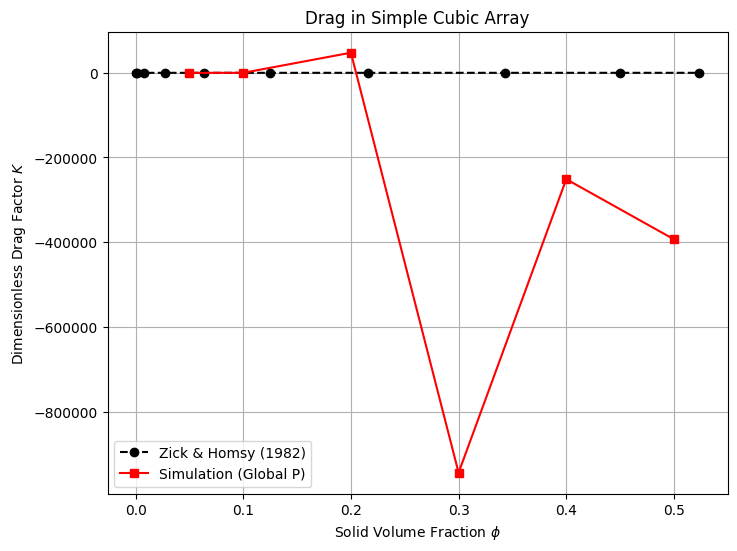

In [5]:
# Plotting
phi_vals = [r['phi'] for r in results]
k_sims = [r['k_sim'] for r in results]
k_refs = [r['k_ref'] for r in results]
phi_Zick_Homsy = [0.000125, 0.001, 0.008, 0.027, 0.064, 0.125, 0.216, 0.343, 0.45, 0.5236]
k_Zick_Homsy = [1.096, 1.212, 1.525, 2.008, 2.810, 4.292, 7.442, 15.4, 28.1, 42.1]

plt.figure(figsize=(8, 6))
plt.plot(phi_Zick_Homsy, k_Zick_Homsy, 'k--o', label='Zick & Homsy (1982)')
plt.plot(phi_vals, k_sims, 'r-s', label='Simulation (Global P)')
plt.xlabel('Solid Volume Fraction $\phi$')
plt.ylabel('Dimensionless Drag Factor $K$')
plt.title('Drag in Simple Cubic Array')
plt.grid(True)
plt.legend()
plt.savefig('output/param_sweep_plot.png')
plt.show()

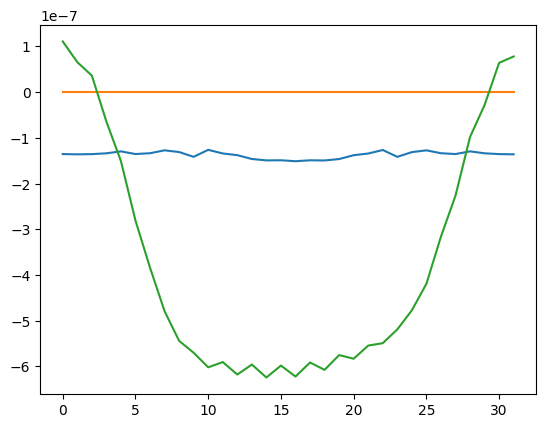

In [6]:
u= np.array(simulator.solver.get_u())
u = u.reshape((res_n, res_n, res_n), order='F')
u_sup = np.mean(u,axis=(1,2))
plt.plot(u_sup)
plt.plot(u[:,res_n//2,res_n//2 ])
plt.plot(u[:,0,0])
plt.show()


## 2. Grid Convergence Study
We test resolution effects for the densest case.

In [7]:
phi_dense = 0.40
resolutions = [32, 64, 96, 128, 160, 256]

convergence_results = []

print(f"Running Grid Convergence for phi={phi_dense}...")
for res in resolutions:
    simulator = SimulationRunner(phi_dense, res)
    k_sim, _ = simulator.run(save_output=False)
    convergence_results.append((res, k_sim))

    print(f"\nGrid Convergence Results (phi={phi_dense}):")
    print(f"{'N':<5} {'K_sim':<10}")
    print("-" * 15)
    for r in convergence_results:
        print(f"{r[0]:<5} {r[1]:<10.4f}")

# Plot Convergence
res_vals = [r[0] for r in convergence_results]
k_vals = [r[1] for r in convergence_results]

plt.figure(figsize=(8, 6))
plt.plot(res_vals, k_vals, 'b-o')
plt.xlabel('Grid Resolution N')
plt.ylabel('K Factor')
plt.title(f'Grid Convergence ($\phi={phi_dense}$)')
plt.grid(True)
plt.savefig('output/grid_convergence.png')
plt.show()

<>:26: SyntaxWarning: invalid escape sequence '\p'
<>:26: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_2435697/1415492716.py:26: SyntaxWarning: invalid escape sequence '\p'
  plt.title(f'Grid Convergence ($\phi={phi_dense}$)')


Running Grid Convergence for phi=0.4...
Running phi=0.400, Res=32^3, dt=1.0000...
IBM Geometry Updated.
  Pressure/Center: 2336 IBM cells
  U-Face: 2356 IBM cells, 17236 fluid cells
  V-Face: 2356 IBM cells, 17236 fluid cells
  W-Face: 2356 IBM cells, 17236 fluid cells
  K_sim = -251213.2326 (Time: 50.51s)


/tmp/ipykernel_2435697/1415492716.py:26: SyntaxWarning: invalid escape sequence '\p'
  plt.title(f'Grid Convergence ($\phi={phi_dense}$)')


ValueError: too many values to unpack (expected 2)